In [6]:
import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df["TotalCharges"].value_counts().head(20)

TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
19.65     8
45.3      7
19.55     7
20.15     6
19.45     6
20.25     6
20.45     5
20.3      5
74.7      4
70.6      4
44        4
75.3      4
20.4      4
19.85     4
49.9      4
Name: count, dtype: int64

In [3]:
df["TotalCharges"].tail(20)

7023     6479.4
7024    3626.35
7025     1679.4
7026     403.35
7027     931.55
7028    4326.25
7029     263.05
7030      39.25
7031     3316.1
7032      75.75
7033    2625.25
7034    6886.25
7035     1495.1
7036      743.3
7037     1419.4
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, dtype: object

In [8]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df["customerID"].duplicated().sum()

np.int64(0)

In [10]:
df = df.drop("customerID", axis=1)

In [7]:
df = df.drop("customerID", axis=1)

KeyError: "['customerID'] not found in axis"

In [11]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [13]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [14]:
df = df.dropna(subset=["TotalCharges"])

In [15]:
df.shape

(7032, 20)

In [16]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [17]:
X.shape

(7032, 19)

In [18]:
y.shape

(7032,)

In [19]:
y.value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [20]:
y = y.map({"No": 0, "Yes": 1})

In [21]:
y.value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [22]:
X.select_dtypes(include="object").columns

C:\Users\haris\AppData\Local\Temp\ipykernel_13592\2213039483.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

numerical_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


C:\Users\haris\AppData\Local\Temp\ipykernel_13592\1966751759.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include="object").columns.tolist()


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("numerical", "passthrough", numerical_cols)
    ]
)

In [26]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [27]:
print("Before preprocessing:", X_train.shape)
print("After preprocessing:", X_train_processed.shape)

Before preprocessing: (5625, 19)
After preprocessing: (5625, 45)


In [28]:
import xgboost as xgb

print(xgb.__version__)

3.4.1


In [29]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import xgboost as xgb

print(xgb.__version__)

3.4.1


In [31]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

In [32]:
model.fit(X_train_processed, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [33]:
y_pred = model.predict(X_test_processed)

In [34]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7903340440653873

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



In [35]:
import joblib

joblib.dump(model, "model_v1.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

print("Model V1 and preprocessor saved successfully!")

Model V1 and preprocessor saved successfully!


In [36]:
import os

print(os.path.exists("model_v1.pkl"))
print(os.path.exists("preprocessor.pkl"))

True
True


In [37]:
import joblib

joblib.dump(model, "model_v1.pkl")
joblib.dump(preprocessor, "preprocessor_v1.pkl")

print("Model V1 saved successfully!")

Model V1 saved successfully!


In [38]:
import os

print("Model:", os.path.exists("model_v1.pkl"))
print("Preprocessor:", os.path.exists("preprocessor_v1.pkl"))

Model: True
Preprocessor: True


In [39]:
import json

model_info = {
    "model_version": "v1",
    "algorithm": "XGBoost",
    "training_samples": int(X_train.shape[0]),
    "test_samples": int(X_test.shape[0]),
    "features_before_encoding": int(X_train.shape[1]),
    "features_after_encoding": int(X_train_processed.shape[1]),
    "accuracy": float(accuracy)
}

with open("model_v1_metadata.json", "w") as f:
    json.dump(model_info, f, indent=4)

print("Model metadata saved successfully!")
print(model_info)

Model metadata saved successfully!
{'model_version': 'v1', 'algorithm': 'XGBoost', 'training_samples': 5625, 'test_samples': 1407, 'features_before_encoding': 19, 'features_after_encoding': 45, 'accuracy': 0.7903340440653873}


In [40]:
import os

files = [
    "model_v1.pkl",
    "preprocessor_v1.pkl",
    "model_v1_metadata.json"
]

for file in files:
    print(file, "→", os.path.exists(file))

model_v1.pkl → True
preprocessor_v1.pkl → True
model_v1_metadata.json → True


In [44]:
%pip install mlflow

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\haris\\OneDrive\\Desktop\\intelligent-self-evolving-mlops\\.venv\\Lib\\site-packages\\PIL\\TiffTags.py'
Check the permissions.


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached mlflow-3.16.0-py3-none-any.whl.metadata (50 kB)
  Using cached mlflow_skinny-3.16.0-py3-none-any.whl.metadata (50 kB)
  Using cached mlflow_tracing-3.16.0-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.5-py3-none-any.whl.metadata (5.4 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached aiohttp-3.14.3-cp314-cp314-win_amd64.whl.metadata (8.5 kB)
  Using cached alembic-1.19.2-py3-none-any.whl.metadata (7.3 kB)
  Using cached cryptography-50.0.1-cp311-abi3-win_amd64.whl.metadata (4.3 kB)
  Using cached docker-7.2.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached skops-0.14.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached sqlalchemy-2.0.52-cp314-cp314-win_amd64.whl.metadata (9.9 kB)
  Using cached cachetools-7.1.8-py3-none-any.whl.metadata (5.5 kB)
  Using cached databricks_sdk-0.136

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\haris\\OneDrive\\Desktop\\intelligent-self-evolving-mlops\\.venv\\Lib\\site-packages\\mlflow\\protos\\databricks_pb2.py'
Check the permissions.


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
import mlflow

print(mlflow.__version__)

3.16.0


In [46]:
import mlflow

mlflow.set_experiment("Telco_Customer_Churn")

print("MLflow experiment is ready!")

2026/09/08 21:19:50 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/08 21:19:50 INFO mlflow.store.db.utils: Updating database tables
2026/09/08 21:19:54 INFO mlflow.tracking.fluent: Experiment with name 'Telco_Customer_Churn' does not exist. Creating a new experiment.


MLflow experiment is ready!


In [47]:
import os

mlflow_dir = os.path.abspath("mlruns")

os.makedirs(mlflow_dir, exist_ok=True)

print(mlflow_dir)

c:\Users\haris\OneDrive\Desktop\intelligent-self-evolving-mlops\mlruns


In [48]:
import mlflow

mlflow.set_tracking_uri("file:///" + mlflow_dir.replace("\\", "/"))

print("MLflow tracking location:")
print(mlflow.get_tracking_uri())

MLflow tracking location:
file:///c:/Users/haris/OneDrive/Desktop/intelligent-self-evolving-mlops/mlruns


In [49]:
mlflow.set_experiment("Telco_Customer_Churn")

print("MLflow experiment is ready!")

MlflowException: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.

In [ ]:
import mlflow
import os

db_path = os.path.abspath("mlflow.db")

mlflow.set_tracking_uri("sqlite:///" + db_path)

print("Tracking URI:")
print(mlflow.get_tracking_uri())

Tracking URI:
sqlite:///c:\Users\haris\OneDrive\Desktop\intelligent-self-evolving-mlops\mlflow.db



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached aiohttp-3.14.3-cp314-cp314-win_amd64.whl.metadata (8.5 kB)
  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached sqlalchemy-2.0.52-cp314-cp314-win_amd64.whl.metadata (9.9 kB)
  Using cached protobuf-7.36.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached python_dotenv-1.2.3-py3-none-any.whl.metadata (29 kB)
  Using cached pyyaml-6.0.3-cp314-cp314-win_amd64.whl.metadata (2.4 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached aiohappyeyeballs-2.7.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached frozenlist-1.8.0-cp314-cp314-win_amd64.whl.metadata (21 kB)
  Using cached multidict-6.7.1-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached propcache-0.5.2-cp314-cp314-win_amd64.whl.metadata (17 kB)
  Using cached yarl-1.24.5-cp314-cp314-win_amd64.whl.metadata (

In [51]:
mlflow.set_experiment("Telco_Customer_Churn")

print("MLflow experiment is ready!")

MLflow experiment is ready!


In [52]:
experiment = mlflow.get_experiment_by_name("Telco_Customer_Churn")

print("Experiment name:", experiment.name)
print("Experiment ID:", experiment.experiment_id)

Experiment name: Telco_Customer_Churn
Experiment ID: 1


In [53]:
import mlflow
import mlflow.xgboost

with mlflow.start_run(run_name="XGBoost_Model_V1"):

    # Model information
    mlflow.log_param("model_version", "v1")
    mlflow.log_param("algorithm", "XGBoost")

    # XGBoost parameters
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 4)
    mlflow.log_param("learning_rate", 0.05)

    # Dataset information
    mlflow.log_param("training_samples", X_train.shape[0])
    mlflow.log_param("test_samples", X_test.shape[0])
    mlflow.log_param("features_after_encoding", X_train_processed.shape[1])

    # Model performance
    mlflow.log_metric("accuracy", accuracy)

    # Save XGBoost model to MLflow
    mlflow.xgboost.log_model(
        model,
        name="xgboost_model"
    )

    print("Model V1 logged successfully!")

Model V1 logged successfully!


In [54]:
import os

print("Current files:")
print(os.listdir())
import joblib

model = joblib.load("model_v1.pkl")
preprocessor = joblib.load("preprocessor_v1.pkl")

print("Model and preprocessor loaded successfully!")
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
df = df.drop("customerID", axis=1)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df = df.dropna(subset=["TotalCharges"])

X = df.drop("Churn", axis=1)
y = df["Churn"].map({"No": 0, "Yes": 1})

print(X.shape)
print(y.shape)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_processed)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Current files:
['.git', '.gitignore', '.venv', 'api', 'data', 'deployment', 'ml.ipynb', 'mlflow.db', 'mlruns', 'model_v1.pkl', 'model_v1_metadata.json', 'monitoring_stack', 'notebooks', 'preprocessor.pkl', 'preprocessor_v1.pkl', 'README.md', 'reports', 'requirements.txt', 'src', 'tests', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']
Model and preprocessor loaded successfully!
(7043, 21)
(7032, 19)
(7032,)
(5625, 19)
(1407, 19)
(5625, 45)
(1407, 45)
Accuracy: 0.7903340440653873


In [55]:
import mlflow
import mlflow.xgboost

# Make sure MLflow uses your SQLite database
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# Select your experiment
mlflow.set_experiment("Telco_Customer_Churn")

with mlflow.start_run(run_name="XGBoost_Model_V1"):

    # Model information
    mlflow.log_param("model_version", "v1")
    mlflow.log_param("algorithm", "XGBoost")

    # Model parameters
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 4)
    mlflow.log_param("learning_rate", 0.05)

    # Dataset information
    mlflow.log_param("training_samples", X_train.shape[0])
    mlflow.log_param("test_samples", X_test.shape[0])
    mlflow.log_param(
        "features_after_encoding",
        X_train_processed.shape[1]
    )

    # Performance
    mlflow.log_metric("accuracy", accuracy)

    # Save model to MLflow
    mlflow.xgboost.log_model(
        model,
        name="xgboost_model"
    )

    print("✅ Model V1 logged successfully!")

✅ Model V1 logged successfully!


In [56]:
runs = mlflow.search_runs()

print("Number of runs:", len(runs))
print("\nAvailable columns:")
print(runs.columns.tolist())

Number of runs: 2

Available columns:
['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time', 'end_time', 'metrics.accuracy', 'params.features_after_encoding', 'params.n_estimators', 'params.learning_rate', 'params.algorithm', 'params.training_samples', 'params.max_depth', 'params.model_version', 'params.test_samples', 'tags.mlflow.user', 'tags.mlflow.runName', 'tags.mlflow.source.type', 'tags.mlflow.source.name']


In [57]:
print(runs)

                             run_id experiment_id    status  \
0  39fddbde98a248748130828a775c806d             1  FINISHED   
1  2563f8d09385464aa71e6507e8870316             1  FINISHED   

                                        artifact_uri  \
0  file:c:/Users/haris/OneDrive/Desktop/intellige...   
1  file:c:/Users/haris/OneDrive/Desktop/intellige...   

                        start_time                         end_time  \
0 2026-09-08 15:50:36.944000+00:00 2026-09-08 15:50:42.849000+00:00   
1 2026-09-08 15:50:22.583000+00:00 2026-09-08 15:50:32.787000+00:00   

   metrics.accuracy params.features_after_encoding params.n_estimators  \
0          0.790334                             45                 200   
1          0.790334                             45                 200   

  params.learning_rate params.algorithm params.training_samples  \
0                 0.05          XGBoost                    5625   
1                 0.05          XGBoost                    5625   

  

In [58]:
import os

print("Model exists:", os.path.exists("model_v1.pkl"))
print("Preprocessor exists:", os.path.exists("preprocessor_v1.pkl"))
print("Metadata exists:", os.path.exists("model_v1_metadata.json"))


Model exists: True
Preprocessor exists: True
Metadata exists: True


In [59]:
import os
os.getcwd()

'c:\\Users\\haris\\OneDrive\\Desktop\\intelligent-self-evolving-mlops'

In [60]:
import os

print(os.listdir())

['.git', '.gitignore', '.venv', 'api', 'data', 'deployment', 'ml.ipynb', 'mlflow.db', 'mlruns', 'model_v1.pkl', 'model_v1_metadata.json', 'monitoring_stack', 'notebooks', 'preprocessor.pkl', 'preprocessor_v1.pkl', 'README.md', 'reports', 'requirements.txt', 'src', 'tests', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [61]:
import os

print(os.path.exists("model_v1.pkl"))
print(os.path.exists("preprocessor_v1.pkl"))

True
True


In [62]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_processed, y_train)

log_pred = log_model.predict(X_test_processed)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


c:\Users\haris\OneDrive\Desktop\intelligent-self-evolving-mlops\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

rf_pred = rf_model.predict(X_test_processed)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [64]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train_processed, y_train)

dt_pred = dt_model.predict(X_test_processed)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Predictions
predictions = {
    "Logistic Regression": log_pred,
    "Random Forest": rf_pred,
    "Decision Tree": dt_pred,
    "XGBoost": y_pred
}

results = []

for name, pred in predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-Score": f1_score(y_test, pred)
    })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.789623,0.602094,0.614973,0.608466
1,Logistic Regression,0.802416,0.644578,0.572193,0.606232
2,XGBoost,0.790334,0.625397,0.526738,0.571843
3,Random Forest,0.786780,0.624161,0.497326,0.553571


In [66]:
best_model_name = comparison_df.loc[0, "Model"]

print("Best Model:", best_model_name)
print("F1-Score:", comparison_df.loc[0, "F1-Score"])
print("Accuracy:", comparison_df.loc[0, "Accuracy"])

Best Model: Decision Tree
F1-Score: 0.6084656084656085
Accuracy: 0.7896233120113717


In [67]:
model_map = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "Decision Tree": dt_model,
    "XGBoost": model
}

best_model = model_map[best_model_name]

print("✅ Selected:", best_model_name)

✅ Selected: Decision Tree


In [68]:
import joblib

joblib.dump(best_model, "model_best.pkl")

print("✅ Best model saved as model_best.pkl")

✅ Best model saved as model_best.pkl


In [69]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Telco_Customer_Churn")

with mlflow.start_run(run_name="Model_Comparison_V1"):

    # Log which model was selected
    mlflow.log_param("selection_metric", "F1-Score")
    mlflow.log_param("best_model", best_model_name)

    # Log performance of all models
    for _, row in comparison_df.iterrows():
        model_name = row["Model"]

        mlflow.log_metric(
            f"{model_name}_accuracy",
            row["Accuracy"]
        )

        mlflow.log_metric(
            f"{model_name}_precision",
            row["Precision"]
        )

        mlflow.log_metric(
            f"{model_name}_recall",
            row["Recall"]
        )

        mlflow.log_metric(
            f"{model_name}_f1",
            row["F1-Score"]
        )

    # Log the selected model's main metrics
    best_row = comparison_df.iloc[0]

    mlflow.log_metric("best_accuracy", best_row["Accuracy"])
    mlflow.log_metric("best_precision", best_row["Precision"])
    mlflow.log_metric("best_recall", best_row["Recall"])
    mlflow.log_metric("best_f1_score", best_row["F1-Score"])

    # Save selected model to MLflow
    mlflow.sklearn.log_model(
        best_model,
        "best_model"
    )

print("✅ Model comparison logged to MLflow!")

2026/09/08 21:21:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Model comparison logged to MLflow!


In [70]:
import pandas as pd
import numpy as np

# Make a copy of the cleaned dataset
data = df.copy()

# Create reference data
reference_data = data.sample(
    n=3000,
    random_state=42
).copy()

# Create simulated production data
production_data = data.drop(
    reference_data.index
).sample(
    n=3000,
    random_state=100
).copy()

print("Reference data:", reference_data.shape)
print("Production data:", production_data.shape)

Reference data: (3000, 20)
Production data: (3000, 20)


In [71]:
print("REFERENCE DATA")
print(reference_data["SeniorCitizen"].value_counts(normalize=True))

print("\nPRODUCTION DATA")
print(production_data["SeniorCitizen"].value_counts(normalize=True))

REFERENCE DATA
SeniorCitizen
0    0.843333
1    0.156667
Name: proportion, dtype: float64

PRODUCTION DATA
SeniorCitizen
0    0.832
1    0.168
Name: proportion, dtype: float64


In [72]:
from scipy.stats import ks_2samp

numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for column in numerical_columns:

    statistic, p_value = ks_2samp(
        reference_data[column],
        production_data[column]
    )

    print(f"\nFeature: {column}")
    print(f"KS Statistic: {statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value < 0.05:
        print("⚠️ Drift detected")
    else:
        print("✅ No significant drift")


Feature: tenure
KS Statistic: 0.0250
P-value: 0.3056
✅ No significant drift

Feature: MonthlyCharges
KS Statistic: 0.0150
P-value: 0.8885
✅ No significant drift

Feature: TotalCharges
KS Statistic: 0.0183
P-value: 0.6945
✅ No significant drift


In [73]:
# Create a copy of production data
drifted_data = production_data.copy()

# Simulate a change in customer behavior
drifted_data["MonthlyCharges"] = drifted_data["MonthlyCharges"] * 1.30

print("Original average MonthlyCharges:")
print(production_data["MonthlyCharges"].mean())

print("\nDrifted average MonthlyCharges:")
print(drifted_data["MonthlyCharges"].mean())

Original average MonthlyCharges:
64.7611

Drifted average MonthlyCharges:
84.18943


In [74]:
statistic, p_value = ks_2samp(
    reference_data["MonthlyCharges"],
    drifted_data["MonthlyCharges"]
)

print("KS Statistic:", round(statistic, 4))
print("P-value:", round(p_value, 6))

if p_value < 0.05:
    print("⚠️ DRIFT DETECTED")
else:
    print("✅ NO SIGNIFICANT DRIFT")

KS Statistic: 0.311
P-value: 0.0
⚠️ DRIFT DETECTED


In [75]:
from scipy.stats import ks_2samp

def detect_numerical_drift(reference_data, current_data, columns, threshold=0.05):
    
    results = []

    for column in columns:
        
        statistic, p_value = ks_2samp(
            reference_data[column],
            current_data[column]
        )
        
        drift = p_value < threshold
        
        results.append({
            "Feature": column,
            "KS_Statistic": statistic,
            "P_Value": p_value,
            "Drift": drift
        })

    return pd.DataFrame(results)

In [76]:
drift_results = detect_numerical_drift(
    reference_data,
    production_data,
    numerical_columns
)

drift_results

,Feature,KS_Statistic,P_Value,Drift
0,tenure,0.025000,0.305642,False
1,MonthlyCharges,0.015000,0.888539,False
2,TotalCharges,0.018333,0.694540,False


In [77]:
drift_results = detect_numerical_drift(
    reference_data,
    drifted_data,
    numerical_columns
)

drift_results

,Feature,KS_Statistic,P_Value,Drift
0,tenure,0.025000,3.056419e-01,False
1,MonthlyCharges,0.311000,1.558111e-128,True
2,TotalCharges,0.018333,6.945404e-01,False


In [92]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Probability predictions
y_prob = model.predict_proba(X_test_processed)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("MODEL PERFORMANCE ANALYSIS")
print("--------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print("ROC-AUC  :", roc_auc)
current_f1 = f1

print("Current Model F1-Score:", round(current_f1, 4))

MODEL PERFORMANCE ANALYSIS
--------------------------
Accuracy : 0.7903340440653873
Precision: 0.6253968253968254
Recall   : 0.5267379679144385
F1-Score : 0.5718432510885341
ROC-AUC  : 0.8371119370920067
Current Model F1-Score: 0.5718


Confusion Matrix:
[[915 118]
 [177 197]]


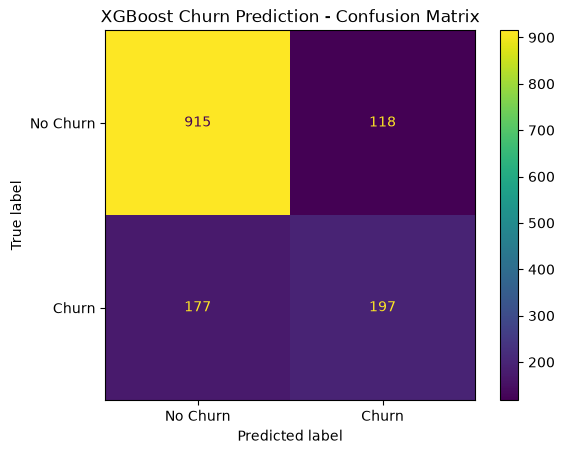

In [93]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("XGBoost Churn Prediction - Confusion Matrix")
plt.show()

In [94]:
print("Classification Report")
print("---------------------")

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

Classification Report
---------------------
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1033
       Churn       0.63      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



In [95]:
# Causal analysis - churn rate by important customer factors

causal_columns = [
    "Contract",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaymentMethod",
    "PaperlessBilling",
    "Partner",
    "Dependents"
]

for column in causal_columns:
    print("\n====================================")
    print("Factor:", column)
    print("====================================")

    churn_rate = (
        df.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    print(churn_rate)


Factor: Contract
Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64

Factor: InternetService
InternetService
Fiber optic    41.892765
DSL            18.998344
No              7.434211
Name: Churn, dtype: float64

Factor: OnlineSecurity
OnlineSecurity
No                     41.778667
Yes                    14.640199
No internet service     7.434211
Name: Churn, dtype: float64

Factor: TechSupport
TechSupport
No                     41.647465
Yes                    15.196078
No internet service     7.434211
Name: Churn, dtype: float64

Factor: PaymentMethod
PaymentMethod
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: Churn, dtype: float64

Factor: PaperlessBilling
PaperlessBilling
Yes    33.589251
No     16.375698
Name: Churn, dtype: float64

Factor: Partner
Partner
No     32.976092
Yes    19.717065
Name: 

In [96]:
# Calculate churn rate differences

causal_results = []

for column in causal_columns:

    rates = (
        df.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
    )

    difference = rates.max() - rates.min()

    causal_results.append({
        "Factor": column,
        "Highest_Churn_Rate": rates.max(),
        "Lowest_Churn_Rate": rates.min(),
        "Difference": difference
    })

causal_df = pd.DataFrame(causal_results)

causal_df = causal_df.sort_values(
    "Difference",
    ascending=False
)

causal_df

,Factor,Highest_Churn_Rate,Lowest_Churn_Rate,Difference
0,Contract,42.709677,2.848665,39.861013
1,InternetService,41.892765,7.434211,34.458554
2,OnlineSecurity,41.778667,7.434211,34.344457
3,TechSupport,41.647465,7.434211,34.213255
4,PaymentMethod,45.285412,15.253123,30.032289
5,PaperlessBilling,33.589251,16.375698,17.213553
7,Dependents,31.279140,15.531205,15.747935
6,Partner,32.976092,19.717065,13.259028


In [97]:
# DIGITAL TWIN - Create a simulated customer

digital_twin = df.drop(columns=["Churn"]).iloc[[0]].copy()

print("Original Customer:")
display(digital_twin)

Original Customer:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85


In [98]:
# Predict original customer's churn probability

digital_twin_processed = preprocessor.transform(digital_twin)

original_probability = model.predict_proba(
    digital_twin_processed
)[:, 1][0]

print("Original Churn Probability:",
      round(original_probability * 100, 2), "%")

Original Churn Probability: 65.53 %


In [99]:
# Create a simulated version of the customer

digital_twin_changed = digital_twin.copy()

digital_twin_changed["Contract"] = "Two year"

# Process simulated customer
changed_processed = preprocessor.transform(
    digital_twin_changed
)

changed_probability = model.predict_proba(
    changed_processed
)[:, 1][0]

print("Original Churn Probability:",
      round(original_probability * 100, 2), "%")

print("After Contract Change:",
      round(changed_probability * 100, 2), "%")

print("Change:",
      round((changed_probability - original_probability) * 100, 2),
      "percentage points")

Original Churn Probability: 65.53 %
After Contract Change: 21.77 %
Change: -43.77 percentage points


In [100]:
# Digital Twin - Multiple What-If Scenarios

contracts = [
    "Month-to-month",
    "One year",
    "Two year"
]

for contract in contracts:

    simulated_customer = digital_twin.copy()
    simulated_customer["Contract"] = contract

    processed = preprocessor.transform(
        simulated_customer
    )

    probability = model.predict_proba(
        processed
    )[:, 1][0]

    print(
        contract,
        "->",
        round(probability * 100, 2),
        "% churn probability"
    )

Month-to-month -> 65.53 % churn probability
One year -> 23.95 % churn probability
Two year -> 21.77 % churn probability


In [101]:
# DECISION ENGINE

DRIFT_THRESHOLD = 0.05
F1_THRESHOLD = 0.60

print("Decision Engine configured")
print("Drift threshold:", DRIFT_THRESHOLD)
print("F1-score threshold:", F1_THRESHOLD)

Decision Engine configured
Drift threshold: 0.05
F1-score threshold: 0.6


In [102]:
# Check whether any feature has drifted

drift_detected = drift_results["Drift"].any()

print("Drift detected:", drift_detected)

Drift detected: True


In [103]:
current_f1 = f1

print("Current Model F1-Score:", round(current_f1, 4))

Current Model F1-Score: 0.5718


In [104]:
# Decision Engine

if drift_detected and current_f1 < F1_THRESHOLD:
    decision = "RETRAIN"
    reason = "Drift detected and model performance is below threshold."

elif drift_detected:
    decision = "MONITOR"
    reason = "Drift detected, but model performance is still acceptable."

elif current_f1 < F1_THRESHOLD:
    decision = "RETRAIN"
    reason = "Model performance is below threshold."

else:
    decision = "CONTINUE"
    reason = "No significant drift and model performance is acceptable."

print("Decision:", decision)
print("Reason:", reason)

Decision: RETRAIN
Reason: Drift detected and model performance is below threshold.


In [105]:
# ARCS - Drift Score

drift_score = drift_results["KS_Statistic"].mean()

print("Drift Score:", round(drift_score, 4))

Drift Score: 0.1181


In [106]:
# ARCS - Performance Risk

target_f1 = 0.60

performance_risk = max(
    0,
    (target_f1 - current_f1) / target_f1
)

print("Current F1:", round(current_f1, 4))
print("Performance Risk:", round(performance_risk, 4))

Current F1: 0.5718
Performance Risk: 0.0469


In [107]:
# ARCS Calculation

arcs = (
    0.5 * drift_score +
    0.5 * performance_risk
)

arcs = min(max(arcs, 0), 1)

print("Drift Score:", round(drift_score, 4))
print("Performance Risk:", round(performance_risk, 4))
print("ARCS:", round(arcs, 4))
print("ARCS (%):", round(arcs * 100, 2), "%")

Drift Score: 0.1181
Performance Risk: 0.0469
ARCS: 0.0825
ARCS (%): 8.25 %


In [108]:
# ARCS Decision

if arcs >= 0.70:
    arcs_decision = "HIGH - Retraining Recommended"
elif arcs >= 0.40:
    arcs_decision = "MEDIUM - Monitor and Simulate"
else:
    arcs_decision = "LOW - Continue Current Model"

print("ARCS Decision:", arcs_decision)

ARCS Decision: LOW - Continue Current Model


In [109]:
# STEP 11 - AUTO RETRAINING ENGINE

from src.retraining.auto_retraining import auto_retrain

retraining_result = auto_retrain(
    arcs_score=arcs,
    model=best_model,
    X_train=X_train_processed,
    y_train=y_train,
    X_test=X_test_processed,
    y_test=y_test,
    threshold=0.70
)

retraining_required = retraining_result["retraining_required"]

print("\nRetraining Required:", retraining_required)

if retraining_required:
    retrained_model = retraining_result["model"]
    retrained_validation = retraining_result["validation"]

    print("\nRetrained Model Validation:")
    print(retrained_validation)
else:
    retrained_model = best_model
    retrained_validation = None

========== AUTO RETRAINING ==========
ARCS Score: 0.0825
Retraining Threshold: 0.7
🟢 ARCS is below retraining threshold.
No retraining required.

Retraining Required: False


In [123]:
# TEST AUTO-RETRAINING BRANCH
# Use a temporary ARCS score above the threshold

test_arcs = 0.80

test_retraining_result = auto_retrain(
    arcs_score=test_arcs,
    model=best_model,
    X_train=X_train_processed,
    y_train=y_train,
    X_test=X_test_processed,
    y_test=y_test,
    threshold=0.70
)

print("\nTest Retraining Required:",
      test_retraining_result["retraining_required"])

if test_retraining_result["retraining_required"]:
    print("\nRetrained Model Validation:")
    print(test_retraining_result["validation"])

========== AUTO RETRAINING ==========
ARCS Score: 0.8
Retraining Threshold: 0.7
🔴 ARCS is above retraining threshold.
Retraining required.
✅ Model retraining completed successfully.
========== RETRAINED MODEL VALIDATION ==========
Accuracy : 0.7896
Precision: 0.6021
Recall   : 0.615
F1-Score : 0.6085
========== AUTO RETRAINING COMPLETE ==========

Test Retraining Required: True

Retrained Model Validation:
{'accuracy': 0.7896, 'precision': 0.6021, 'recall': 0.615, 'f1': 0.6085}


In [110]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score


def retrain_model(X_train_processed, y_train, X_test_processed, y_test):

    print("Starting model retraining...")

    new_model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    )

    # Train the new model
    new_model.fit(
        X_train_processed,
        y_train
    )

    # Predictions
    new_predictions = new_model.predict(
        X_test_processed
    )

    # Performance
    new_accuracy = accuracy_score(
        y_test,
        new_predictions
    )

    new_f1 = f1_score(
        y_test,
        new_predictions
    )

    print("Retraining completed.")
    print("New Accuracy:", round(new_accuracy, 4))
    print("New F1-Score:", round(new_f1, 4))

    return new_model, new_accuracy, new_f1

In [111]:
new_model, new_accuracy, new_f1 = retrain_model(
    X_train_processed,
    y_train,
    X_test_processed,
    y_test
)

Starting model retraining...
Retraining completed.
New Accuracy: 0.7903
New F1-Score: 0.5718


In [112]:
print("========== MODEL COMPARISON ==========")

print("Old Model Accuracy:", round(accuracy, 4))
print("New Model Accuracy:", round(new_accuracy, 4))

print("Old Model F1:", round(f1, 4))
print("New Model F1:", round(new_f1, 4))

========== MODEL COMPARISON ==========
Old Model Accuracy: 0.7903
New Model Accuracy: 0.7903
Old Model F1: 0.5718
New Model F1: 0.5718


In [113]:
# STEP 12 - MODEL VALIDATION

print("========== MODEL VALIDATION ==========")

accuracy_improved = new_accuracy > accuracy
f1_improved = new_f1 > f1

print("Old Accuracy:", round(accuracy, 4))
print("New Accuracy:", round(new_accuracy, 4))

print("Old F1-Score:", round(f1, 4))
print("New F1-Score:", round(new_f1, 4))

if accuracy_improved or f1_improved:
    print("\n✅ New model performs better.")
    print("Validation Result: ACCEPT NEW MODEL")
else:
    print("\n⚠️ New model does not improve performance.")
    print("Validation Result: KEEP OLD MODEL")

========== MODEL VALIDATION ==========
Old Accuracy: 0.7903
New Accuracy: 0.7903
Old F1-Score: 0.5718
New F1-Score: 0.5718

⚠️ New model does not improve performance.
Validation Result: KEEP OLD MODEL


In [136]:
# STEP 15 - MODEL VALIDATION

print("========== MODEL VALIDATION ==========")

if not retraining_required:

    print("No retraining was performed.")
    print("Best Model Accuracy:", round(best_accuracy, 4))
    print("Best Model F1-Score:", round(best_f1, 4))
    print("Validation Result: KEEP CURRENT MODEL")

    promoted_model = best_model

else:

    new_accuracy = retrained_validation["accuracy"]
    new_precision = retrained_validation["precision"]
    new_recall = retrained_validation["recall"]
    new_f1 = retrained_validation["f1"]

    print("Old Accuracy:", round(best_accuracy, 4))
    print("New Accuracy:", round(new_accuracy, 4))
    print("Old F1-Score:", round(best_f1, 4))
    print("New F1-Score:", round(new_f1, 4))

    accuracy_improved = new_accuracy > best_accuracy
    f1_improved = new_f1 > best_f1

    if accuracy_improved or f1_improved:

        print("\nNew model performs better.")
        print("Validation Result: ACCEPT NEW MODEL")

        promoted_model = retrained_model

    else:

        print("\nNew model does not improve performance.")
        print("Validation Result: KEEP OLD MODEL")

        promoted_model = best_model

========== MODEL VALIDATION ==========
No retraining was performed.
Best Model Accuracy: 0.7896
Best Model F1-Score: 0.6085
Validation Result: KEEP CURRENT MODEL


In [137]:
# STEP 16 - MODEL PROMOTION

import joblib
import os
import shutil

print("========== MODEL PROMOTION ==========")

if retraining_required:

    if new_accuracy > best_accuracy or new_f1 > best_f1:

        print("New model passed validation.")
        print("Promoting new model to production.")

        # Backup current production model
        if os.path.exists("model_v1.pkl"):
            shutil.copy2(
                "model_v1.pkl",
                "model_v1_backup.pkl"
            )
            print("Backup created: model_v1_backup.pkl")

        # Save promoted model
        joblib.dump(
            promoted_model,
            "model_v1.pkl"
        )

        print("New model saved as model_v1.pkl")
        print("Production model updated.")

    else:

        print("New model did not improve performance.")
        print("Keeping existing production model.")

else:

    print("No retraining was required.")
    print("Keeping existing production model.")

========== MODEL PROMOTION ==========
No retraining was required.
Keeping existing production model.


In [138]:
# STEP 13 - MODEL PROMOTION

import joblib
import os
import shutil

if retraining_required:
    if new_accuracy > accuracy or new_f1 > f1:

        print("========== MODEL PROMOTION ==========")
        print("New model passed validation.")
        print("Promoting new model to production.")

        # Backup current production model
        if os.path.exists("model_v1.pkl"):
            shutil.copy2(
                "model_v1.pkl",
                "model_v1_backup.pkl"
            )
            print("Backup created: model_v1_backup.pkl")

        # Save promoted model
        joblib.dump(
            promoted_model,
            "model_v1.pkl"
        )

        print("New model saved as model_v1.pkl")
        print("Production model updated.")

    else:
        print("========== MODEL PROMOTION ==========")
        print("New model did not improve performance.")
        print("Keeping existing production model.")

else:
    print("========== MODEL PROMOTION ==========")
    print("No retraining was required.")
    print("Keeping existing production model.")

========== MODEL PROMOTION ==========
No retraining was required.
Keeping existing production model.


In [139]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [140]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [141]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_processed)

print("SHAP analysis completed!")
print("SHAP shape:", shap_values.shape)

SHAP analysis completed!
SHAP shape: (1407, 45)


In [142]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print("Number of SHAP features:", shap_values.shape[1])

Number of features: 45
Number of SHAP features: 45


In [143]:
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Importance",
    ascending=False
)

print("========== TOP 10 CHURN FEATURES ==========")
print(shap_importance.head(10))

========== TOP 10 CHURN FEATURES ==========
                                        Feature  Importance
32         categorical__Contract_Month-to-month    0.774364
42                            numerical__tenure    0.439182
43                    numerical__MonthlyCharges    0.287337
14               categorical__OnlineSecurity_No    0.244874
44                      numerical__TotalCharges    0.182740
23                  categorical__TechSupport_No    0.174828
39  categorical__PaymentMethod_Electronic check    0.141591
8                 categorical__MultipleLines_No    0.138723
12     categorical__InternetService_Fiber optic    0.133488
34               categorical__Contract_Two year    0.112838


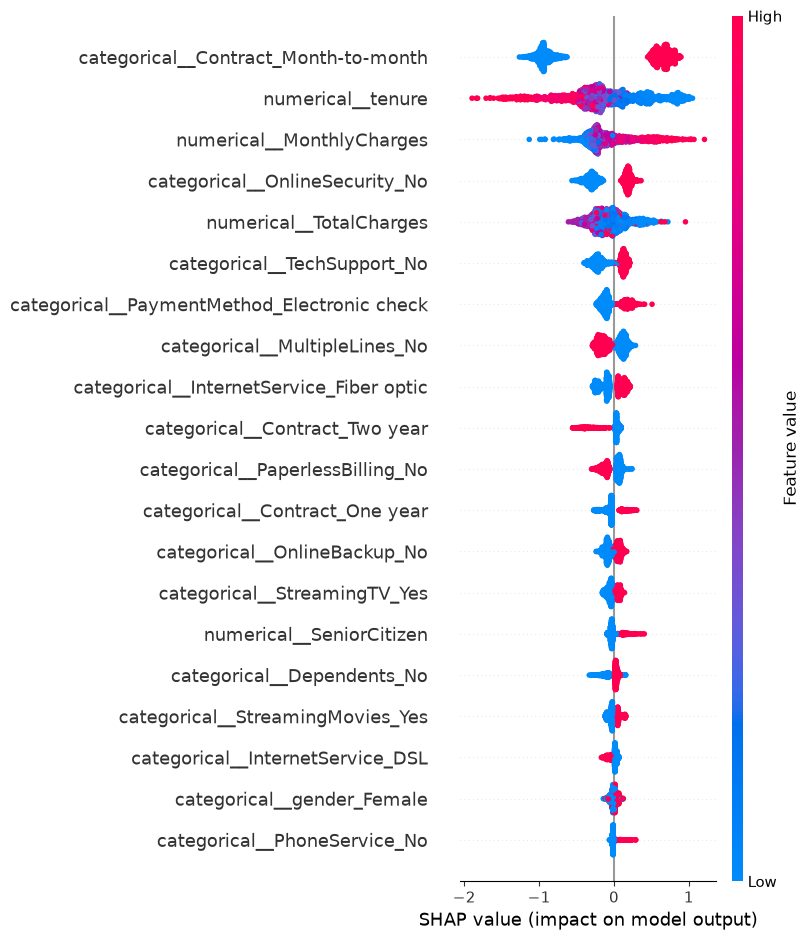

In [144]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

In [145]:
# ==========================================
# STEP 14 - OUTCOME ANALYSIS
# ==========================================

print("========================================")
print("       FINAL OUTCOME ANALYSIS")
print("========================================")

print("\n1. MODEL PERFORMANCE")
print("--------------------")
print("Model: XGBoost")
print("Accuracy:", round(accuracy, 4))
print("F1-Score:", round(f1, 4))

print("\n2. DRIFT ANALYSIS")
print("-----------------")
print("Drift Score:", round(drift_score, 4))

print("\n3. PERFORMANCE RISK")
print("-------------------")
print("Performance Risk:", round(performance_risk, 4))

print("\n4. ARCS DECISION")
print("----------------")
print("ARCS Score:", round(arcs, 4))
print("ARCS (%):", round(arcs * 100, 2), "%")

if arcs < 0.70:
    print("Decision: LOW - Continue Current Model")
else:
    print("Decision: HIGH - Retraining Required")

print("\n5. RETRAINING")
print("-------------")
print("Old Accuracy:", round(accuracy, 4))
print("New Accuracy:", round(new_accuracy, 4))
print("Old F1:", round(f1, 4))
print("New F1:", round(new_f1, 4))

print("\n6. VALIDATION")
print("-------------")
print("Validation Status:", validation_status)

print("\n7. TOP CHURN FEATURES")
print("---------------------")

top_features = shap_importance.head(10)

for i, row in enumerate(top_features.itertuples(), 1):
    print(
        i,
        "-",
        row.Feature,
        ":",
        round(row.Importance, 4)
    )

print("\n========================================")
print("       PROJECT PIPELINE COMPLETED")
print("========================================")

       FINAL OUTCOME ANALYSIS

1. MODEL PERFORMANCE
--------------------
Model: XGBoost
Accuracy: 0.7903
F1-Score: 0.5718

2. DRIFT ANALYSIS
-----------------
Drift Score: 0.1181

3. PERFORMANCE RISK
-------------------
Performance Risk: 0.0469

4. ARCS DECISION
----------------
ARCS Score: 0.0825
ARCS (%): 8.25 %
Decision: LOW - Continue Current Model

5. RETRAINING
-------------
Old Accuracy: 0.7903
New Accuracy: 0.7903
Old F1: 0.5718
New F1: 0.5718

6. VALIDATION
-------------
Validation Status: PASS

7. TOP CHURN FEATURES
---------------------
1 - categorical__Contract_Month-to-month : 0.7744
2 - numerical__tenure : 0.4392
3 - numerical__MonthlyCharges : 0.2873
4 - categorical__OnlineSecurity_No : 0.2449
5 - numerical__TotalCharges : 0.1827
6 - categorical__TechSupport_No : 0.1748
7 - categorical__PaymentMethod_Electronic check : 0.1416
8 - categorical__MultipleLines_No : 0.1387
9 - categorical__InternetService_Fiber optic : 0.1335
10 - categorical__Contract_Two year : 0.1128

    

In [146]:
cd

C:\Users\haris


In [147]:
# STEP 14 - VALIDATE BEST MODEL BEFORE PROMOTION

from sklearn.metrics import accuracy_score, f1_score

print("========== BEST MODEL BASELINE ==========")

best_model_pred = best_model.predict(X_test_processed)

best_accuracy = accuracy_score(y_test, best_model_pred)
best_f1 = f1_score(y_test, best_model_pred, zero_division=0)

print("Best Model:", best_model_name)
print("Best Model Accuracy:", round(best_accuracy, 4))
print("Best Model F1-Score:", round(best_f1, 4))

========== BEST MODEL BASELINE ==========
Best Model: Decision Tree
Best Model Accuracy: 0.7896
Best Model F1-Score: 0.6085


In [149]:
import os

print("Current notebook directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())

Current notebook directory:
C:\Users\haris

Files in current directory:
['.AltairRapidMiner', '.anaconda', '.android', '.antigravity', '.arduinoIDE', '.azure', '.cache', '.cagent', '.codex', '.conda', '.condarc', '.config', '.continuum', '.copilot', '.cursor', '.docker', '.emulator_console_auth_token', '.expo', '.gemini', '.git', '.gitconfig', '.gradle', '.idlerc', '.insightface', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.kube', '.lesshst', '.m2', '.mamba', '.matplotlib', '.node_repl_history', '.ollama', '.packettracer', '.streamlit', '.viminfo', '.VirtualBox', '.vscode', '.vscode-shared', 'A3_all_in_one.ipynb', 'agent', 'ALL_IS_WELL_ML.ipynb', 'anaconda3', 'AndroidStudioProjects', 'AppData', 'Application Data', 'archive (1).zip', 'archive (4).zip', 'assessment_02_Internshala.ipynb', 'battery-report.html', 'cd', 'Cisco Packet Tracer 8.2.2', 'Common_Indian_Plants.zip', 'Common_Indian_Plants_extracted', 'Contacts', 'Cookies', 'covid_data_2020-2021.csv', 'credit_card_fraud

In [150]:
import os

PROJECT_DIR = r"C:\Users\haris\OneDrive\Desktop\intelligent-self-evolving-mlops"

os.chdir(PROJECT_DIR)

print("Changed to:")
print(os.getcwd())

Changed to:
C:\Users\haris\OneDrive\Desktop\intelligent-self-evolving-mlops


In [151]:
print("model_v1.pkl exists:", os.path.exists("model_v1.pkl"))
print("preprocessor_v1.pkl exists:", os.path.exists("preprocessor_v1.pkl"))

model_v1.pkl exists: True
preprocessor_v1.pkl exists: True


In [152]:
# STEP 17 - VERIFY PRODUCTION MODEL

import os
import joblib

print("========== PRODUCTION MODEL CHECK ==========")

model_path = "model_v1.pkl"

if os.path.exists(model_path):

    print("Production model found:", model_path)
    print("File size:", round(os.path.getsize(model_path) / 1024, 2), "KB")

    production_model = joblib.load(model_path)

    print("Model loaded successfully.")
    print("Model type:", type(production_model).__name__)

else:

    print("ERROR: Production model not found.")

========== PRODUCTION MODEL CHECK ==========
Production model found: model_v1.pkl
File size: 321.48 KB
Model loaded successfully.
Model type: XGBClassifier


In [154]:
# STEP 19 - VERIFY API PRODUCTION MODEL

import requests

print("========== API PRODUCTION CHECK ==========")

response = requests.get("http://localhost:8000/health")

print("Status Code:", response.status_code)
print("Response:", response.json())

========== API PRODUCTION CHECK ==========
Status Code: 200
Response: {'status': 'healthy', 'model': 'model_v1.pkl'}
